In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [19]:
import pandas as pd

colunas = pd.read_csv(
    "MICRODADOS_ENEM_2023.csv",
    sep=";",
    encoding="latin1",
    nrows=0
).columns

colunas

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO',
       'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC',
       'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
       'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA',
       'SG_UF_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC',
       'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC',
       'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
       'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH', 'TX_RESPOSTAS_LC',
       'TX_RESPOSTAS_MT', 'TP_LINGUA', 'TX_GABARITO_CN', 'TX_GABARITO_CH',
       'TX_GABARITO_LC', 'TX_GABARITO_MT', 'TP_STATUS_REDACAO',
       'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
       'NU_NOTA_COMP5', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004',

In [27]:
cols = [
    "TP_SEXO",
    "TP_COR_RACA",
    "TP_ESCOLA",
    "TP_FAIXA_ETARIA",
    "SG_UF_PROVA",
    "Q006", 
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]

In [26]:
import pandas as pd

df = pd.read_csv(
    "MICRODADOS_ENEM_2023.csv",
    sep=";",
    encoding="latin1",
    usecols=cols,
    low_memory=False
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3933955 entries, 0 to 3933954
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   TP_FAIXA_ETARIA  int64  
 1   TP_SEXO          object 
 2   TP_COR_RACA      int64  
 3   TP_ESCOLA        int64  
 4   SG_UF_PROVA      object 
 5   NU_NOTA_CN       float64
 6   NU_NOTA_CH       float64
 7   NU_NOTA_LC       float64
 8   NU_NOTA_MT       float64
 9   NU_NOTA_REDACAO  float64
 10  Q006             object 
dtypes: float64(5), int64(3), object(3)
memory usage: 330.2+ MB


In [28]:
import pandas as pd

cols = [
    "TP_SEXO",
    "TP_COR_RACA",
    "TP_ESCOLA",
    "TP_FAIXA_ETARIA",
    "SG_UF_PROVA",
    "Q006",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO",
    "TP_PRESENCA_CN",
    "TP_PRESENCA_CH",
    "TP_PRESENCA_LC",
    "TP_PRESENCA_MT"
]

chunks = pd.read_csv(
    "MICRODADOS_ENEM_2023.csv",
    sep=";",
    encoding="latin1",
    usecols=cols,
    chunksize=200_000,
    low_memory=False
)

lista = []

for chunk in chunks:
    chunk = chunk[
        (chunk["TP_PRESENCA_CN"] == 1) &
        (chunk["TP_PRESENCA_CH"] == 1) &
        (chunk["TP_PRESENCA_LC"] == 1) &
        (chunk["TP_PRESENCA_MT"] == 1)
    ]
    lista.append(chunk)

df = pd.concat(lista)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2678264 entries, 2 to 3933953
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   TP_FAIXA_ETARIA  int64  
 1   TP_SEXO          object 
 2   TP_COR_RACA      int64  
 3   TP_ESCOLA        int64  
 4   SG_UF_PROVA      object 
 5   TP_PRESENCA_CN   int64  
 6   TP_PRESENCA_CH   int64  
 7   TP_PRESENCA_LC   int64  
 8   TP_PRESENCA_MT   int64  
 9   NU_NOTA_CN       float64
 10  NU_NOTA_CH       float64
 11  NU_NOTA_LC       float64
 12  NU_NOTA_MT       float64
 13  NU_NOTA_REDACAO  float64
 14  Q006             object 
dtypes: float64(5), int64(7), object(3)
memory usage: 326.9+ MB


In [32]:
df.to_csv(
    "enem_2023_filtrado.csv",
    index=False,
    encoding="utf-8"
)

In [34]:
df = pd.read_csv("enem_2023_filtrado.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2678264 entries, 0 to 2678263
Data columns (total 15 columns):
 #   Column           Dtype  
---  ------           -----  
 0   TP_FAIXA_ETARIA  int64  
 1   TP_SEXO          object 
 2   TP_COR_RACA      int64  
 3   TP_ESCOLA        int64  
 4   SG_UF_PROVA      object 
 5   TP_PRESENCA_CN   int64  
 6   TP_PRESENCA_CH   int64  
 7   TP_PRESENCA_LC   int64  
 8   TP_PRESENCA_MT   int64  
 9   NU_NOTA_CN       float64
 10  NU_NOTA_CH       float64
 11  NU_NOTA_LC       float64
 12  NU_NOTA_MT       float64
 13  NU_NOTA_REDACAO  float64
 14  Q006             object 
dtypes: float64(5), int64(7), object(3)
memory usage: 306.5+ MB


In [36]:
df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].astype("category")
df["TP_COR_RACA"] = df["TP_COR_RACA"].astype("category")
df["TP_ESCOLA"] = df["TP_ESCOLA"].astype("category")
df["SG_UF_PROVA"] = df["SG_UF_PROVA"].astype("category")
df["Q006"] = df["Q006"].astype("category")

In [38]:
df["nota_media"] = df[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]
].mean(axis=1)

ANÁLISE 1 — ESCOLA PÚBLICA × PRIVADA

In [57]:
map_escola = {
    1: "Não respondeu",
    2: "Pública",
    3: "Privada"
}

df["TP_ESCOLA_LABEL"] = df["TP_ESCOLA"].map(map_escola)

<Axes: xlabel='TP_ESCOLA_LABEL', ylabel='nota_media'>

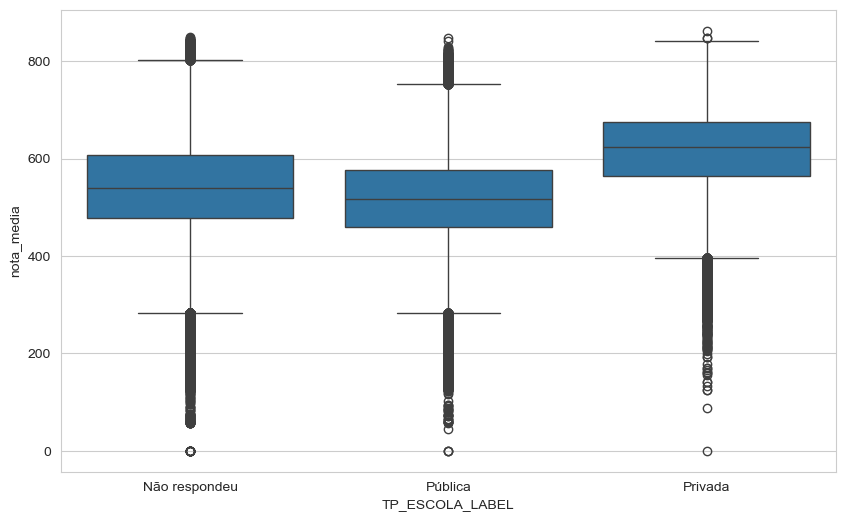

In [59]:
sns.boxplot(
    data=df,
    x="TP_ESCOLA_LABEL",
    y="nota_media"
)

ANÁLISE 2 — RENDA FAMILIAR × DESEMPENHO

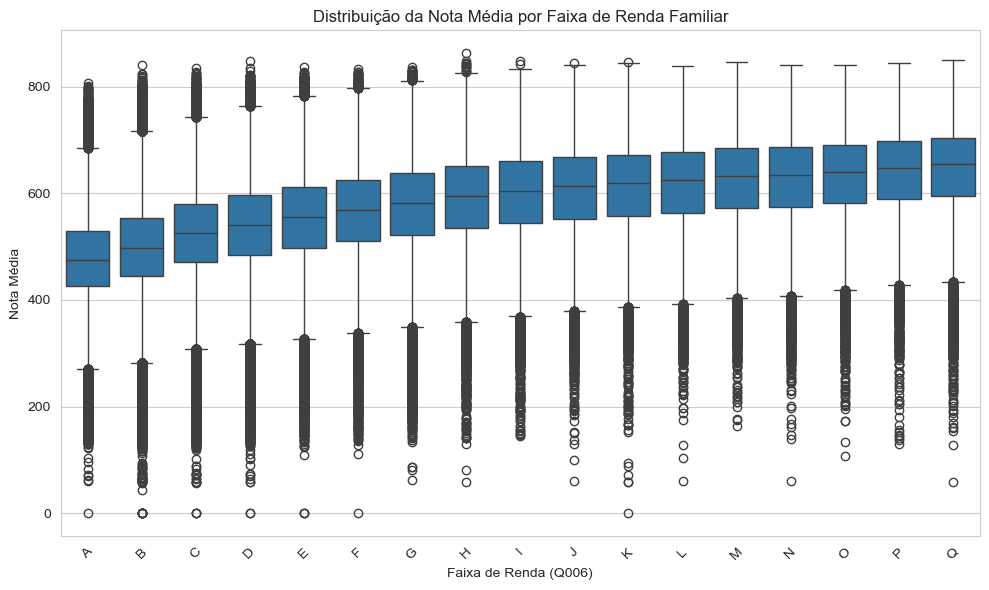

In [44]:
sns.boxplot(
    data=df,
    x="Q006",
    y="nota_media"
)

plt.title("Distribuição da Nota Média por Faixa de Renda Familiar")
plt.xlabel("Faixa de Renda (Q006)")
plt.ylabel("Nota Média")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ANÁLISE 3 — COR/RAÇA × NOTA

<Axes: xlabel='TP_COR_RACA_LABEL', ylabel='nota_media'>

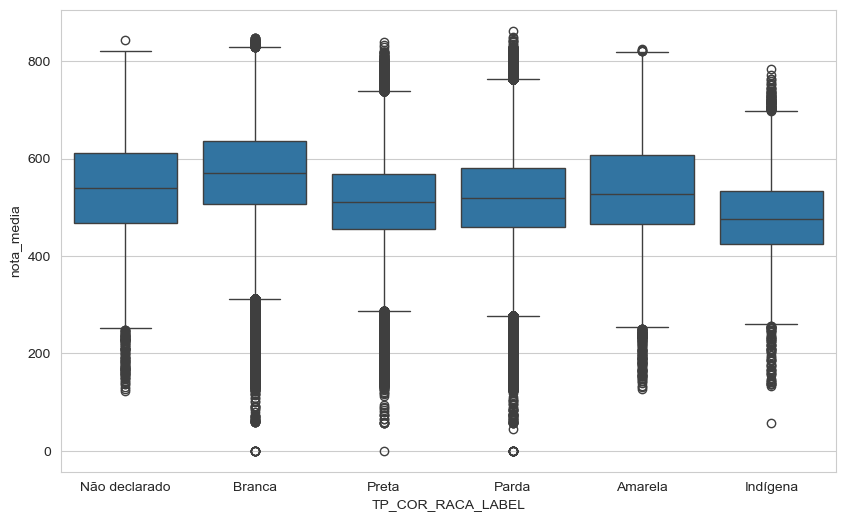

In [63]:
map_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

df["TP_COR_RACA_LABEL"] = df["TP_COR_RACA"].map(map_raca)

sns.boxplot(
    data=df,
    x="TP_COR_RACA_LABEL",
    y="nota_media"
)

ANÁLISE 4 — DESEMPENHO POR ESTADO

In [50]:
media_uf = (
    df.groupby("SG_UF_PROVA")["nota_media"]
    .mean()
    .sort_values()
)

C:\Users\amand\AppData\Local\Temp\ipykernel_16732\575693438.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("SG_UF_PROVA")["nota_media"]


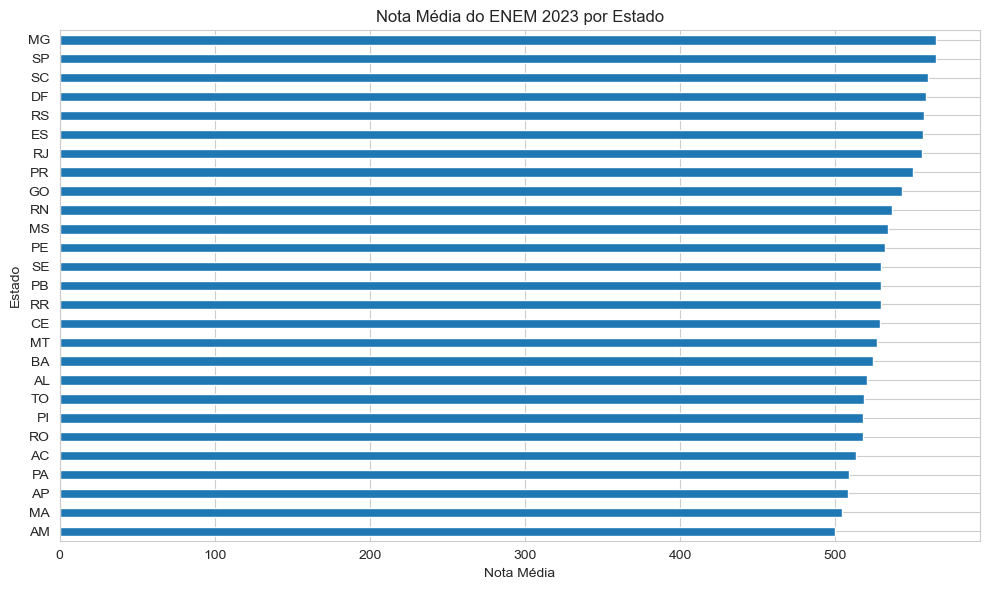

In [52]:
media_uf.plot(kind="barh")

plt.title("Nota Média do ENEM 2023 por Estado")
plt.xlabel("Nota Média")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

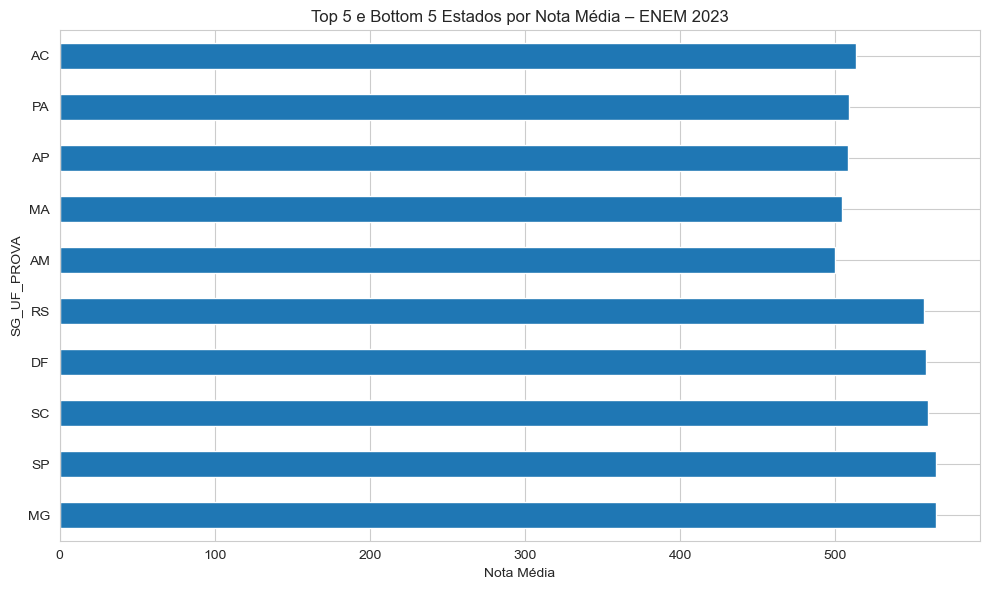

In [65]:
top5 = media_uf.sort_values(ascending=False).head(5)
bottom5 = media_uf.sort_values().head(5)

pd.concat([top5, bottom5]).plot(kind="barh")
plt.title("Top 5 e Bottom 5 Estados por Nota Média – ENEM 2023")
plt.xlabel("Nota Média")
plt.tight_layout()
plt.show()

ANÁLISE 5 — FAIXA ETÁRIA × NOTA

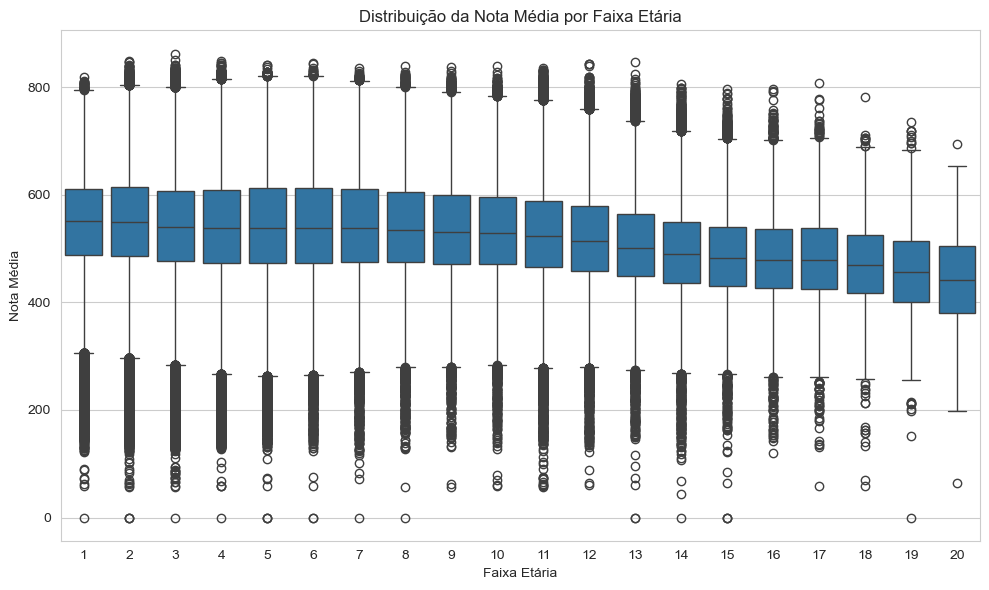

In [55]:
sns.boxplot(
    data=df,
    x="TP_FAIXA_ETARIA",
    y="nota_media"
)

plt.title("Distribuição da Nota Média por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Nota Média")
plt.tight_layout()
plt.show()

In [69]:
os.makedirs("images", exist_ok=True)

# =========================
# ANÁLISE 1 — Escola x Nota
# =========================
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="TP_ESCOLA", y="nota_media")
plt.title("Nota Média do ENEM 2023 por Tipo de Escola")
plt.xlabel("Tipo de Escola (1=Pública | 2=Privada)")
plt.ylabel("Nota Média")
plt.tight_layout()
plt.savefig("images/analise1_escola.png", dpi=300)
plt.close()

# =========================
# ANÁLISE 2 — Renda x Nota
# =========================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Q006", y="nota_media")
plt.title("Nota Média do ENEM 2023 por Faixa de Renda Familiar")
plt.xlabel("Faixa de Renda (Q006)")
plt.ylabel("Nota Média")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/analise2_renda.png", dpi=300)
plt.close()

# =========================
# ANÁLISE 3 — Cor/Raça x Nota
# =========================
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="TP_COR_RACA", y="nota_media")
plt.title("Nota Média do ENEM 2023 por Cor/Raça")
plt.xlabel("Cor/Raça (INEP)")
plt.ylabel("Nota Média")
plt.tight_layout()
plt.savefig("images/analise3_cor_raca.png", dpi=300)
plt.close()

# =========================
# ANÁLISE 4 — Estado x Nota
# =========================
media_estado = df.groupby("SG_UF_PROVA")["nota_media"].mean().sort_values()

plt.figure(figsize=(9,7))
media_estado.plot(kind="barh")
plt.title("Nota Média do ENEM 2023 por Estado")
plt.xlabel("Nota Média")
plt.ylabel("UF")
plt.tight_layout()
plt.savefig("images/analise4_estado.png", dpi=300)
plt.close()

# =========================
# ANÁLISE 5 — Faixa Etária x Nota
# =========================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="TP_FAIXA_ETARIA", y="nota_media")
plt.title("Nota Média do ENEM 2023 por Faixa Etária")
plt.xlabel("Faixa Etária (INEP)")
plt.ylabel("Nota Média")
plt.tight_layout()
plt.savefig("images/analise5_faixa_etaria.png", dpi=300)
plt.close()

print("Todos os gráficos foram salvos na pasta 'images/'")

C:\Users\amand\AppData\Local\Temp\ipykernel_16732\3031948088.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_estado = df.groupby("SG_UF_PROVA")["nota_media"].mean().sort_values()


Todos os gráficos foram salvos na pasta 'images/'
